In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [29]:
df = pd.read_excel('/content/drive/MyDrive/amazon.xlsx')
df.head(2)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹ 399,"₹ 1,099",0.64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹ 199,₹ 349,0.43,4.0,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...


In [30]:
df.shape

(1465, 16)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   object 
 4   actual_price         1465 non-null   object 
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [32]:
df.describe()

,discount_percentage,rating
count,1465.000000,1465.000000
mean,0.476915,4.096655
std,0.216359,0.291587
min,0.000000,2.000000
25%,0.320000,4.000000
50%,0.500000,4.100000
75%,0.630000,4.300000
max,0.940000,5.000000


In [33]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [36]:
df['product_id'].nunique()

1351

In [37]:
df['review_id'].nunique()

1194

In [39]:
df['rating'] = pd.to_numeric(df['rating'])  #converting object into numeric
print(df['rating'].mean())

4.0966552901023885


In [40]:
df['discount_percentage'].mean()


np.float64(0.4769146757679181)

In [47]:
df['actual_price'] = (
    df['actual_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace('Rs.', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['actual_price'] = pd.to_numeric(df['actual_price'])
print(df['actual_price'].mean())


5444.990634812287


In [48]:
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace('Rs.', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['discounted_price'] = pd.to_numeric(df['discounted_price'])
print(df['discounted_price'].mean())

3125.3108737201364


In [51]:
price_analysis = df[['actual_price', 'discounted_price']].describe()
price_analysis

,actual_price,discounted_price
count,1465.000000,1465.000000
mean,5444.990635,3125.310874
std,10874.826864,6944.304394
min,39.000000,39.000000
25%,800.000000,325.000000
50%,1650.000000,799.000000
75%,4295.000000,1999.000000
max,139900.000000,77990.000000


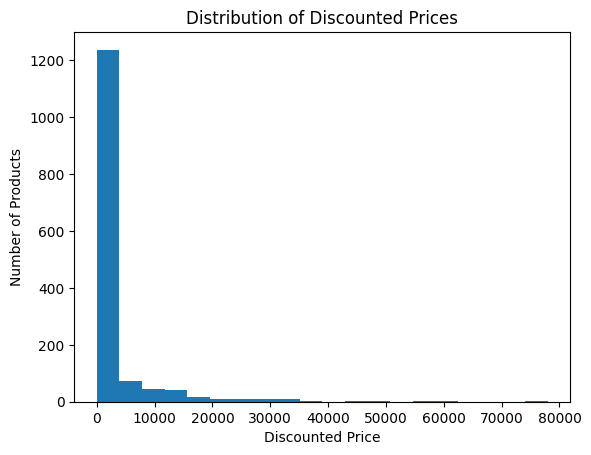

In [59]:
plt.hist(df['discounted_price'] , bins=20)
plt.title('Distribution of Discounted Prices')
plt.xlabel('Discounted Price')
plt.ylabel('Number of Products')
plt.show()

In [60]:
rating_counts = df['rating'].value_counts().sort_index()

rating_counts

,count
rating,
2.0,1
2.3,1
2.6,1
2.8,2
2.9,1
3.0,4
3.1,4
3.2,2
3.3,16


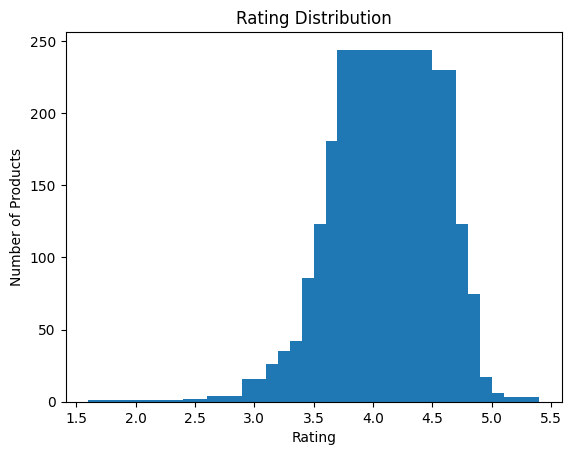

In [61]:
plt.bar(rating_counts.index, rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.show()

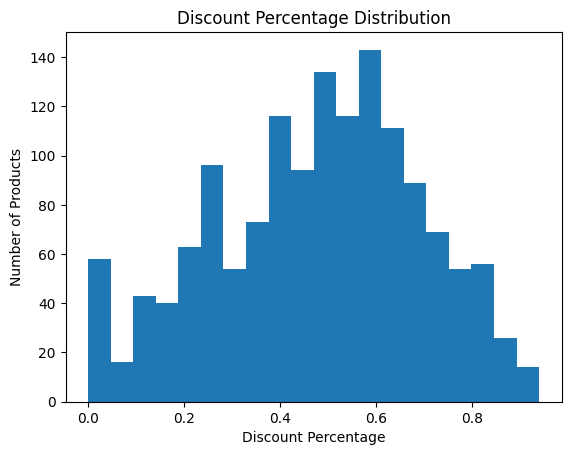

In [62]:
plt.hist(df['discount_percentage'], bins=20)
plt.title('Discount Percentage Distribution')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.show()